In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/logistics_dataset_uncleaned (1).csv")
df.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
0,S981356,O13241,C2917,Jane Smith,jane@,916827957610,Chennai,UK,West,110001.0,...,7342.820681,1779.594970,NaN,South Hub,Mr. Patel,NaN,Card,Yes,Pending,NaN
1,S316311,O56814,C9290,Jane Smith,NaN,918882137895,Delhi,U.K.,East,NaN,...,5630.916919,419.635432,NaN,Central,Mr. Patel,NaN,Cash,Yes,NaN,NaN
2,S470009,O66124,C1239,Amit Kumar,amit@gmail.com,916621089428,Delhi,U.K.,West,560001.0,...,8641.039995,1267.012215,Warehouse A,South Hub,Mr. Patel,High,Online,No,Not Returned,Delayed delivery
3,S459529,O28293,C5966,michael brown,jane@,918061558996,Bangalore,India,North,110001.0,...,3845.086369,1463.660290,Hub C,North Hub,Ms. Verma,NaN,Online,Yes,NaN,Delayed delivery
4,S372486,O40352,C6710,Fatima Noor,NaN,919316399195,Bangalore,NaN,South,400001.0,...,7342.820681,1384.774596,Warehouse B,South Hub,Ms. Verma,Low,NaN,No,Not Returned,Handle with care


In [ ]:
df.shape

(10000, 36)

In [ ]:
df.columns

Index(['Shipment_ID', 'Order_ID', 'Customer_ID', 'Customer_Name', 'Email',
       'Phone', 'City', 'Country', 'Region', 'Postal_Code', 'Product_ID',
       'Product_Name', 'Category', 'Weight_kg', 'Quantity', 'Unit_Price',
       'Total_Price', 'Shipment_Date', 'Delivery_Date', 'Delay_Days', 'Status',
       'Delivery_Mode', 'Vehicle_ID', 'Driver_Name', 'Transport_Type',
       'Route_ID', 'Fuel_Cost', 'Distance_km', 'Delivery_Center',
       'Warehouse_Name', 'Manager_Name', 'Order_Priority', 'Payment_Mode',
       'Insurance', 'Return_Status', 'Remarks'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Shipment_ID      10000 non-null  object 
 1   Order_ID         10000 non-null  object 
 2   Customer_ID      10000 non-null  object 
 3   Customer_Name    8597 non-null   object 
 4   Email            7465 non-null   object 
 5   Phone            10000 non-null  int64  
 6   City             8344 non-null   object 
 7   Country          8592 non-null   object 
 8   Region           7979 non-null   object 
 9   Postal_Code      8020 non-null   float64
 10  Product_ID       10000 non-null  object 
 11  Product_Name     8393 non-null   object 
 12  Category         8320 non-null   object 
 13  Weight_kg        9906 non-null   float64
 14  Quantity         9907 non-null   float64
 15  Unit_Price       9900 non-null   float64
 16  Total_Price      9905 non-null   float64
 17  Shipment_Date

In [ ]:
df.describe()

,Phone,Postal_Code,Weight_kg,Quantity,Unit_Price,Total_Price,Delay_Days,Fuel_Cost,Distance_km
count,1.000000e+04,8020.000000,9906.000000,9907.000000,9900.000000,9905.000000,9909.000000,9889.000000,9904.000000
mean,9.180023e+11,418311.473815,46.416791,9.820127,2442.801298,104069.216407,4.369361,5364.956995,975.102927
std,1.153715e+09,191730.980904,29.874946,5.019782,1388.131533,61167.012418,5.890966,2875.985758,562.175762
min,9.160004e+11,110001.000000,-2.000000,-1.000000,247.931338,1631.407291,-5.000000,103.956957,23.390089
25%,9.170014e+11,400001.000000,18.748749,6.000000,1206.769041,50746.420565,0.000000,3087.753105,523.888063
50%,9.180013e+11,400001.000000,45.087068,10.000000,2634.015917,103142.166946,3.000000,5675.666106,939.145591
75%,9.190007e+11,600001.000000,73.095815,14.000000,3587.724083,149908.959130,10.000000,7753.704802,1456.701958
max,9.199999e+11,600001.000000,98.695250,19.000000,4932.496363,198229.440471,14.000000,9984.617643,1994.252399


In [ ]:
df.isnull().sum()

,0
Shipment_ID,0
Order_ID,0
Customer_ID,0
Customer_Name,1403
Email,2535
Phone,0
City,1656
Country,1408
Region,2021
Postal_Code,1980


A. Duplicates & Missing Values

In [ ]:
df['Customer_Name'] = df['Customer_Name'].fillna('Not Provided')

In [ ]:
cols_to_fill = [
    'Email', 'City', 'Country', 'Region', 'Product_Name', 'Category',
    'Status', 'Delivery_Mode', 'Driver_Name', 'Warehouse_Name',
    'Manager_Name', 'Order_Priority', 'Payment_Mode', 'Insurance',
    'Return_Status', 'Delivery_Center'
]

# Fill missing values with "Unknown"
df[cols_to_fill] = df[cols_to_fill].fillna('Unknown')

In [ ]:
df['Weight_kg'] = df['Weight_kg'].fillna(
    df.groupby('Category')['Weight_kg'].transform('mean')
)
df['Fuel_Cost'] = df['Fuel_Cost'].fillna(
    df.groupby('Transport_Type')['Fuel_Cost'].transform('median')
)
df['Remarks'] = df['Remarks'].fillna("No Remarks")

In [ ]:
mode_value = df['Transport_Type'].mode()[0]
df['Transport_Type'] = df['Transport_Type'].fillna(mode_value)

In [ ]:
df.loc[
    df['Quantity'].isna() & df['Unit_Price'].notna() & df['Total_Price'].notna(),
    'Quantity'
] = df['Total_Price'] / df['Unit_Price']

df.loc[
    df['Unit_Price'].isna() & df['Quantity'].notna() & df['Total_Price'].notna(),
    'Unit_Price'
] = df['Total_Price'] / df['Quantity']

df.loc[
    df['Total_Price'].isna() & df['Quantity'].notna() & df['Unit_Price'].notna(),
    'Total_Price'
] = df['Quantity'] * df['Unit_Price']

In [ ]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Unit_Price'] = df['Unit_Price'].fillna(df['Unit_Price'].median())
df['Total_Price'] = df['Total_Price'].fillna(df['Total_Price'].median())

In [ ]:
df['Fuel_Cost'] = df['Fuel_Cost'].fillna(df['Fuel_Cost'].mean())
df['Distance_km'] = df['Distance_km'].interpolate(method='linear')

In [ ]:
df.isnull().sum()

,0
Shipment_ID,0
Order_ID,0
Customer_ID,0
Customer_Name,0
Email,0
Phone,0
City,0
Country,0
Region,0
Postal_Code,1980


In [ ]:
print(df.duplicated(subset=['Shipment_ID','Order_ID']).sum())

0


Section B – Invalid / Outlier

In [ ]:
df = df[
    (df['Quantity'] > 0) &
    (df['Weight_kg'] > 0) &
    (df['Total_Price'] > 0) &
    (df['Delivery_Date'] >= df['Shipment_Date']) &
    (df['Delay_Days'] >= -1)
]

In [ ]:
def drop_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

cols_to_clean = ['Weight_kg', 'Quantity', 'Unit_Price', 'Total_Price']
df = drop_outliers(df, cols_to_clean)

In [ ]:
# Replace incorrect values
df["Payment_Mode"] = df["Payment_Mode"].replace({
    "Credt": "Credit",
    "Debet": "Debit"
})

df["Status"] = df["Status"].replace({
    "delayed": "Delayed",
    "DELAYED": "Delayed"
})

df["Country"] = df["Country"].replace({
    "us": "USA",
    "U.K.": "UK"
})

print(df[["Payment_Mode","Status","Country"]].head())

   Payment_Mode      Status  Country
4       Unknown     Delayed  Unknown
7          Card  In Transit       UK
8           UPI   Cancelled  Unknown
9         Debit     Delayed    India
15        Debit     Delayed  Unknown


In [ ]:
df = df.drop(df[df['Distance_km'] > 20000].index)

In [ ]:
Q1 = df['Distance_km'].quantile(0.25)
Q3 = df['Distance_km'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Distance_km'] >= lower_bound) &
                    (df['Distance_km'] <= upper_bound)]

print(df_no_outliers)

     Shipment_ID Order_ID Customer_ID  Customer_Name             Email  \
4        S372486   O40352       C6710    Fatima Noor           Unknown   
7        S734726   O77929       C3183  michael brown    amit@gmail.com   
8        S728975   O40008       C3098     Jane Smith    amit@gmail.com   
9        S427342   O36381       C5569       John Doe  john@example.com   
15       S639574   O65339       C2260       John Doe             jane@   
...          ...      ...         ...            ...               ...   
9987     S996729   O86227       C3986  michael brown    amit@gmail.com   
9994     S274987   O34297       C3828     Amit Kumar           Unknown   
9995     S331063   O20146       C9393     Amit Kumar    amit@gmail.com   
9996     S703532   O14424       C5315    Fatima Noor           Unknown   
9997     S684607   O29085       C5106         Li Wei             jane@   

             Phone       City  Country   Region  Postal_Code  ...  \
4     919316399195  Bangalore  Unknown    

In [ ]:
email_pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'
df['Email'] = df['Email'].where(df['Email'].str.match(email_pattern, na=False), np.nan)

print(df)

     Shipment_ID Order_ID Customer_ID  Customer_Name             Email  \
4        S372486   O40352       C6710    Fatima Noor               NaN   
7        S734726   O77929       C3183  michael brown    amit@gmail.com   
8        S728975   O40008       C3098     Jane Smith    amit@gmail.com   
9        S427342   O36381       C5569       John Doe  john@example.com   
15       S639574   O65339       C2260       John Doe               NaN   
...          ...      ...         ...            ...               ...   
9987     S996729   O86227       C3986  michael brown    amit@gmail.com   
9994     S274987   O34297       C3828     Amit Kumar               NaN   
9995     S331063   O20146       C9393     Amit Kumar    amit@gmail.com   
9996     S703532   O14424       C5315    Fatima Noor               NaN   
9997     S684607   O29085       C5106         Li Wei               NaN   

             Phone       City  Country   Region  Postal_Code  ...  \
4     919316399195  Bangalore  Unknown    

In [ ]:
delayed_days = df.loc[df["Delay_Days"] > 5, "Shipment_ID"]
delayed_days.count()

np.int64(1962)

Conditional Filtering

In [ ]:
Orders = df.loc[df['Order_Priority']=="High", ["Order_ID","Order_Priority"]]
Orders.count()

,0
Order_ID,979
Order_Priority,979


In [ ]:
Shipment = df[df['Delivery_Mode']=="Air"]
Shipment.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
17,S789076,O58826,C3367,Li Wei,amit@gmail.com,916820876325,Unknown,india,North,400001.0,...,2530.987075,1267.012215,Warehouse A,North Hub,Ms. Verma,Medium,Debit,Yes,Pending,Check packaging
25,S777803,O75666,C9408,Not Provided,NaN,919138121270,Delhi,USA,South,NaN,...,9138.029149,787.008748,Warehouse B,Central,Mr. Patel,Low,UPI,Unknown,Unknown,Check packaging
40,S478286,O88231,C3295,Not Provided,amit@gmail.com,917364597783,Bangalore,USA,North,560001.0,...,2530.987075,939.145591,Warehouse A,South Hub,Mr. Khan,Low,Cash,Unknown,Pending,Check packaging
50,S275615,O56142,C4762,Jane Smith,NaN,919507190470,Chennai,USA,North,560001.0,...,6663.056267,1406.512023,Hub C,Central,Ms. Verma,Low,Credit,Unknown,Not Returned,No Remarks
67,S440122,O85883,C2314,michael brown,NaN,918121121069,Mumbai,UK,West,NaN,...,4839.546420,787.008748,Hub C,Unknown,Unknown,Unknown,Credit,Yes,Not Returned,Delayed delivery


In [ ]:
Shipment = df[df['Fuel_Cost'] > 8000]
Shipment.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
8,S728975,O40008,C3098,Jane Smith,amit@gmail.com,918298796637,Mumbai,Unknown,East,600001.0,...,8916.361693,65.594470,Warehouse B,North Hub,Mr. Khan,High,UPI,Yes,Not Returned,Check packaging
16,S694897,O55928,C7775,michael brown,NaN,918536798041,Mumbai,USA,South,400001.0,...,8607.492526,490.745004,Warehouse B,Central,Mr. Patel,Medium,Debit,No,Unknown,Handle with care
19,S416457,O85033,C8390,michael brown,NaN,917874365656,mumbai,USA,North,600001.0,...,8813.090633,632.826018,Unknown,Unknown,Mr. Patel,Unknown,Cash,Unknown,Not Returned,Check packaging
22,S476484,O24048,C7410,Not Provided,amit@gmail.com,916066672764,mumbai,UK,South,400001.0,...,8553.133891,173.606764,Warehouse A,South Hub,Mr. Khan,Unknown,Debit,Unknown,Unknown,No Remarks
24,S976996,O72852,C9298,Li Wei,amit@gmail.com,919228642734,mumbai,USA,West,400001.0,...,8138.839000,1248.440028,Warehouse A,Unknown,Mr. Khan,Medium,Card,Unknown,Unknown,Check packaging


In [ ]:
Total_price  = df[df['Total_Price']>100000]
Total_price.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
4,S372486,O40352,C6710,Fatima Noor,NaN,919316399195,Bangalore,Unknown,South,400001.0,...,7342.820681,1384.774596,Warehouse B,South Hub,Ms. Verma,Low,Unknown,No,Not Returned,Handle with care
16,S694897,O55928,C7775,michael brown,NaN,918536798041,Mumbai,USA,South,400001.0,...,8607.492526,490.745004,Warehouse B,Central,Mr. Patel,Medium,Debit,No,Unknown,Handle with care
22,S476484,O24048,C7410,Not Provided,amit@gmail.com,916066672764,mumbai,UK,South,400001.0,...,8553.133891,173.606764,Warehouse A,South Hub,Mr. Khan,Unknown,Debit,Unknown,Unknown,No Remarks
24,S976996,O72852,C9298,Li Wei,amit@gmail.com,919228642734,mumbai,USA,West,400001.0,...,8138.839000,1248.440028,Warehouse A,Unknown,Mr. Khan,Medium,Card,Unknown,Unknown,Check packaging
31,S794002,O70026,C8875,Li Wei,john@example.com,917792931815,Unknown,Unknown,Unknown,600001.0,...,4344.411364,365.217846,Unknown,South Hub,Ms. Verma,High,Online,Yes,Not Returned,No Remarks


In [ ]:
customer = df[(df["Country"]=="india") & (df["Total_Price"]>50000)]
customer.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
17,S789076,O58826,C3367,Li Wei,amit@gmail.com,916820876325,Unknown,india,North,400001.0,...,2530.987075,1267.012215,Warehouse A,North Hub,Ms. Verma,Medium,Debit,Yes,Pending,Check packaging
46,S339307,O84270,C2511,Li Wei,NaN,916200756543,mumbai,india,North,560001.0,...,7133.883833,914.071878,Unknown,South Hub,Ms. Verma,Medium,UPI,Unknown,Unknown,No Remarks
54,S106465,O36476,C6472,Li Wei,amit@gmail.com,916829335273,Unknown,india,North,400001.0,...,7089.920759,643.200256,Warehouse A,South Hub,Mr. Khan,Medium,UPI,Yes,Unknown,No Remarks
84,S209120,O65634,C6193,Not Provided,john@example.com,916457964073,Delhi,india,South,600001.0,...,7652.798286,740.970151,Warehouse B,South Hub,Mr. Khan,High,Unknown,Yes,Returned,Delayed delivery
158,S115457,O75681,C1688,Fatima Noor,amit@gmail.com,918296049319,Bangalore,india,Unknown,600001.0,...,8408.905679,168.366458,Hub C,Central,Mr. Khan,Low,Credit,Unknown,Unknown,Check packaging


In [ ]:
Insurance = df[df['Insurance']=="Yes"]
Insurance.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
8,S728975,O40008,C3098,Jane Smith,amit@gmail.com,918298796637,Mumbai,Unknown,East,600001.0,...,8916.361693,65.594470,Warehouse B,North Hub,Mr. Khan,High,UPI,Yes,Not Returned,Check packaging
9,S427342,O36381,C5569,John Doe,john@example.com,916712246490,Unknown,India,South,110001.0,...,6853.332809,738.698400,Warehouse A,Central,Mr. Patel,Low,Debit,Yes,Pending,No Remarks
17,S789076,O58826,C3367,Li Wei,amit@gmail.com,916820876325,Unknown,india,North,400001.0,...,2530.987075,1267.012215,Warehouse A,North Hub,Ms. Verma,Medium,Debit,Yes,Pending,Check packaging
20,S618003,O67221,C2313,michael brown,amit@gmail.com,918979222732,Chennai,Unknown,East,600001.0,...,6853.332809,709.655395,Hub C,Unknown,Ms. Verma,Medium,Credit,Yes,Pending,No Remarks
31,S794002,O70026,C8875,Li Wei,john@example.com,917792931815,Unknown,Unknown,Unknown,600001.0,...,4344.411364,365.217846,Unknown,South Hub,Ms. Verma,High,Online,Yes,Not Returned,No Remarks


In [ ]:
customer = df[(df["Category"]=="Electronics") & (df["Delivery_Mode"]=="Air")]
customer.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Fuel_Cost,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks
137,S362430,O85256,C2062,Amit Kumar,amit@gmail.com,917001605361,Delhi,USA,West,600001.0,...,8621.622057,1248.440028,Warehouse A,South Hub,Mr. Khan,Medium,Debit,Unknown,Not Returned,No Remarks
325,S581194,O44629,C5160,michael brown,NaN,919313380773,Delhi,India,Unknown,600001.0,...,2556.841848,959.330599,Unknown,South Hub,Unknown,High,Cash,No,Pending,No Remarks
589,S332651,O70398,C9771,Jane Smith,NaN,916991423701,Mumbai,UK,North,600001.0,...,2868.259480,1808.283386,Warehouse A,Unknown,Ms. Verma,Low,Credit,Yes,Unknown,No Remarks
643,S689694,O23014,C9104,Jane Smith,NaN,917581413376,mumbai,USA,West,400001.0,...,178.809623,1513.852223,Hub C,South Hub,Mr. Patel,Unknown,Debit,Yes,Not Returned,No Remarks
713,S254069,O59424,C7659,Amit Kumar,NaN,916882754314,Delhi,india,Unknown,600001.0,...,8481.274237,1134.787063,Unknown,Central,Mr. Khan,Medium,UPI,No,Not Returned,Delayed delivery


In [ ]:
df = df.assign(Revenue = df['Quantity'] * df['Unit_Price'])
df.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Distance_km,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks,Revenue
4,S372486,O40352,C6710,Fatima Noor,NaN,919316399195,Bangalore,Unknown,South,400001.0,...,1384.774596,Warehouse B,South Hub,Ms. Verma,Low,Unknown,No,Not Returned,Handle with care,19145.578691
7,S734726,O77929,C3183,michael brown,amit@gmail.com,917852158344,Chennai,UK,Unknown,400001.0,...,1009.235384,Unknown,North Hub,Mr. Khan,High,Card,Unknown,Pending,No Remarks,24737.388485
8,S728975,O40008,C3098,Jane Smith,amit@gmail.com,918298796637,Mumbai,Unknown,East,600001.0,...,65.594470,Warehouse B,North Hub,Mr. Khan,High,UPI,Yes,Not Returned,Check packaging,21312.364345
9,S427342,O36381,C5569,John Doe,john@example.com,916712246490,Unknown,India,South,110001.0,...,738.698400,Warehouse A,Central,Mr. Patel,Low,Debit,Yes,Pending,No Remarks,50873.602704
15,S639574,O65339,C2260,John Doe,NaN,919440752144,Unknown,Unknown,West,560001.0,...,151.024447,Unknown,North Hub,Unknown,Medium,Debit,Unknown,Returned,Handle with care,17316.171940


In [ ]:
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], format="%Y-%m-%d")
df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'], format="%Y-%m-%d")

df = df.assign(Delivery_Duration = df['Delivery_Date'] - df['Shipment_Date'])

df.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks,Revenue,Delivery_Duration
4,S372486,O40352,C6710,Fatima Noor,NaN,919316399195,Bangalore,Unknown,South,400001.0,...,Warehouse B,South Hub,Ms. Verma,Low,Unknown,No,Not Returned,Handle with care,19145.578691,965 days
7,S734726,O77929,C3183,michael brown,amit@gmail.com,917852158344,Chennai,UK,Unknown,400001.0,...,Unknown,North Hub,Mr. Khan,High,Card,Unknown,Pending,No Remarks,24737.388485,191 days
8,S728975,O40008,C3098,Jane Smith,amit@gmail.com,918298796637,Mumbai,Unknown,East,600001.0,...,Warehouse B,North Hub,Mr. Khan,High,UPI,Yes,Not Returned,Check packaging,21312.364345,1424 days
9,S427342,O36381,C5569,John Doe,john@example.com,916712246490,Unknown,India,South,110001.0,...,Warehouse A,Central,Mr. Patel,Low,Debit,Yes,Pending,No Remarks,50873.602704,1113 days
15,S639574,O65339,C2260,John Doe,NaN,919440752144,Unknown,Unknown,West,560001.0,...,Unknown,North Hub,Unknown,Medium,Debit,Unknown,Returned,Handle with care,17316.171940,864 days


In [ ]:
df[df["Return_Status"] == "Returned"]

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Delivery_Center,Warehouse_Name,Manager_Name,Order_Priority,Payment_Mode,Insurance,Return_Status,Remarks,Revenue,Delivery_Duration
15,S639574,O65339,C2260,John Doe,NaN,919440752144,Unknown,Unknown,West,560001.0,...,Unknown,North Hub,Unknown,Medium,Debit,Unknown,Returned,Handle with care,17316.171940,864 days
48,S196122,O90267,C7159,Not Provided,amit@gmail.com,918646141901,Unknown,india,West,110001.0,...,Hub C,South Hub,Mr. Patel,High,Online,No,Returned,Handle with care,4827.076166,282 days
53,S348688,O42617,C3793,michael brown,amit@gmail.com,916379721447,Chennai,UK,East,560001.0,...,Unknown,North Hub,Unknown,High,Cash,Yes,Returned,No Remarks,41566.932627,282 days
75,S500169,O57638,C6761,John Doe,NaN,918355162443,mumbai,USA,East,NaN,...,Warehouse A,South Hub,Ms. Verma,Medium,UPI,Yes,Returned,No Remarks,35101.764479,256 days
79,S665933,O95206,C9026,Fatima Noor,john@example.com,918359928012,Bangalore,USA,North,560001.0,...,Unknown,South Hub,Mr. Khan,Low,Card,Yes,Returned,Check packaging,33055.501307,1752 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9977,S913811,O78710,C6685,Fatima Noor,amit@gmail.com,919023398511,Unknown,Unknown,South,110001.0,...,Hub C,Unknown,Ms. Verma,Unknown,Unknown,Yes,Returned,No Remarks,45251.862239,863 days
9980,S424262,O34605,C1678,John Doe,amit@gmail.com,917908788202,Mumbai,India,South,560001.0,...,Warehouse B,Unknown,Ms. Verma,Low,Online,Unknown,Returned,Handle with care,56976.776093,700 days
9987,S996729,O86227,C3986,michael brown,amit@gmail.com,918314767100,Unknown,india,East,NaN,...,Warehouse A,Central,Mr. Patel,Medium,Card,No,Returned,No Remarks,44447.994597,1546 days
9994,S274987,O34297,C3828,Amit Kumar,NaN,916274817938,mumbai,india,West,600001.0,...,Warehouse B,South Hub,Ms. Verma,Unknown,Card,Unknown,Returned,No Remarks,34231.591575,527 days


Calculated Columns

In [ ]:
df["Revenue"] = df["Quantity"] * df["Unit_Price"]
df[["Quantity","Unit_Price","Revenue"]].head()

,Quantity,Unit_Price,Revenue
4,9.0,2127.286521,19145.578691
7,10.0,2473.738849,24737.388485
8,11.0,1937.487668,21312.364345
9,11.0,4624.872973,50873.602704
15,7.0,2473.738849,17316.171940


In [ ]:
df["Delivery_Date"] = pd.to_datetime(df["Delivery_Date"])
df["Shipment_Date"] = pd.to_datetime(df["Shipment_Date"])

df["Delivery_Duration"] = df["Delivery_Date"] - df["Shipment_Date"]

df[["Shipment_Date","Delivery_Date","Delivery_Duration"]].head()

,Shipment_Date,Delivery_Date,Delivery_Duration
4,2022-03-04,2024-10-24,965 days
7,2023-01-17,2023-07-27,191 days
8,2020-09-10,2024-08-04,1424 days
9,2022-06-02,2025-06-19,1113 days
15,2020-02-23,2022-07-06,864 days


In [ ]:
df["Fuel_Efficiency"] = df["Distance_km"] / df["Fuel_Cost"]

df[["Distance_km","Fuel_Cost","Fuel_Efficiency"]].head()

,Distance_km,Fuel_Cost,Fuel_Efficiency
4,1384.774596,7342.820681,0.188589
7,1009.235384,352.525220,2.862874
8,65.594470,8916.361693,0.007357
9,738.698400,6853.332809,0.107787
15,151.024447,6663.056267,0.022666


In [ ]:
df["Profit"] = df["Total_Price"] - df["Fuel_Cost"]

df[["Total_Price","Fuel_Cost","Profit"]].head()

,Total_Price,Fuel_Cost,Profit
4,177191.334817,7342.820681,169848.514136
7,18639.484645,352.525220,18286.959426
8,79017.036226,8916.361693,70100.674533
9,90097.764798,6853.332809,83244.431990
15,47175.329705,6663.056267,40512.273438


In [ ]:
df['Delay_Flag'] = np.where(df['Delay_Days'] > 0, 'Yes', 'No')
df[['Delay_Days', 'Delay_Flag']].head()

,Delay_Days,Delay_Flag
4,1.0,Yes
7,4.0,Yes
8,13.0,Yes
9,11.0,Yes
15,11.0,Yes


In [ ]:
df['Order_Priority'].unique()

array(['Low', 'High', 'Medium', 'Unknown'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Payment_Mode_Encoded'] = encoder.fit_transform(df['Payment_Mode'])
df.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Remarks,Revenue,Delivery_Duration,Fuel_Efficiency,Profit,Delay_Flag,Urgency_Level,Payment_Mode_Code,Priority_Code,Payment_Mode_Encoded
4,S372486,O40352,C6710,Fatima Noor,NaN,919316399195,Bangalore,Unknown,South,400001.0,...,Handle With Care,19145.578691,965 days,0.188589,169848.514136,Yes,Low Priority,NaN,1.0,5
7,S734726,O77929,C3183,Michael Brown,Amit@Gmail.Com,917852158344,Chennai,Uk,Unknown,400001.0,...,No Remarks,24737.388485,191 days,2.862874,18286.959426,Yes,Urgent,NaN,3.0,0
8,S728975,O40008,C3098,Jane Smith,Amit@Gmail.Com,918298796637,Mumbai,Unknown,East,600001.0,...,Check Packaging,21312.364345,1424 days,0.007357,70100.674533,Yes,Urgent,4.0,3.0,6
9,S427342,O36381,C5569,John Doe,John@Example.Com,916712246490,Unknown,India,South,110001.0,...,No Remarks,50873.602704,1113 days,0.107787,83244.431990,Yes,Low Priority,3.0,1.0,3
15,S639574,O65339,C2260,John Doe,NaN,919440752144,Unknown,Unknown,West,560001.0,...,Handle With Care,17316.171940,864 days,0.022666,40512.273438,Yes,Normal,3.0,2.0,3


In [ ]:
priority_map = {"High":3,"Medium":2,"Low":1}

df["Priority_Code"] = df["Order_Priority"].map(priority_map)

print(df[["Order_Priority","Priority_Code"]].head())

   Order_Priority  Priority_Code
4             Low            1.0
7            High            3.0
8            High            3.0
9             Low            1.0
15         Medium            2.0


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()
df.head()

,Shipment_ID,Order_ID,Customer_ID,Customer_Name,Email,Phone,City,Country,Region,Postal_Code,...,Remarks,Revenue,Delivery_Duration,Fuel_Efficiency,Profit,Delay_Flag,Urgency_Level,Payment_Mode_Code,Priority_Code,Payment_Mode_Encoded
4,S372486,O40352,C6710,Fatima Noor,NaN,919316399195,Bangalore,Unknown,South,400001.0,...,Handle With Care,19145.578691,965 days,0.188589,169848.514136,Yes,Low Priority,NaN,1.0,5
7,S734726,O77929,C3183,Michael Brown,Amit@Gmail.Com,917852158344,Chennai,Uk,Unknown,400001.0,...,No Remarks,24737.388485,191 days,2.862874,18286.959426,Yes,Urgent,NaN,3.0,0
8,S728975,O40008,C3098,Jane Smith,Amit@Gmail.Com,918298796637,Mumbai,Unknown,East,600001.0,...,Check Packaging,21312.364345,1424 days,0.007357,70100.674533,Yes,Urgent,4.0,3.0,6
9,S427342,O36381,C5569,John Doe,John@Example.Com,916712246490,Unknown,India,South,110001.0,...,No Remarks,50873.602704,1113 days,0.107787,83244.431990,Yes,Low Priority,3.0,1.0,3
15,S639574,O65339,C2260,John Doe,NaN,919440752144,Unknown,Unknown,West,560001.0,...,Handle With Care,17316.171940,864 days,0.022666,40512.273438,Yes,Normal,3.0,2.0,3


In [ ]:
df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'], errors='coerce')
df['Shipment_Date']

,Shipment_Date
4,2022-03-04
7,2023-01-17
8,2020-09-10
9,2022-06-02
15,2020-02-23
...,...
9987,2020-09-19
9994,2021-11-07
9995,2020-08-29
9996,2024-05-28


Sorting / Ranking / Aggregation

In [ ]:
top_customers = (
    df.groupby('Customer_ID', as_index=False)['Total_Price']
    .sum()
    .sort_values(by='Total_Price', ascending=False)
)

top_customers['Rank'] = top_customers['Total_Price'].rank(ascending=False)

top_customers = top_customers.head(10)

print(top_customers)

     Customer_ID    Total_Price  Rank
2315       C7624  577188.541728   1.0
722        C3127  549335.263855   2.0
2861       C9298  535870.449714   3.0
1113       C4267  527081.632140   4.0
2159       C7168  503783.670148   5.0
1919       C6532  493569.450722   6.0
2717       C8874  482258.705022   7.0
107        C1347  474597.941135   8.0
684        C3010  432264.024542   9.0
1883       C6445  430666.008993  10.0


In [ ]:
top_customers = (
    df.groupby('Customer_ID', as_index=False)['Total_Price']
    .sum()
    .sort_values(by='Total_Price', ascending=False)
)

top_customers['Rank'] = top_customers['Total_Price'].rank(ascending=False)

top_customers = top_customers.head(10)

print(top_customers)

City
Bangalore    1690
Delhi        1676
mumbai       1675
Chennai      1666
Mumbai       1637
Name: count, dtype: int64


In [ ]:
delivery_mode_count = df["Delivery_Mode"].value_counts()

print(delivery_mode_count)

Delivery_Mode
Ship       790
Air        785
Rail       778
Road       773
Unknown    742
Name: count, dtype: int64


In [ ]:
avg_delay_days = (df.groupby('Category')['Delay_Days'].mean().reset_index()
    .rename(columns={'Delay_Days': 'Avg_Delay_Days'}))
print(avg_delay_days)

      Category  Avg_Delay_Days
0  Accessories        6.238022
1     Clothing        6.150769
2  Electronics        6.268634
3         Food        6.248050
4    Furniture        6.212766
5      Unknown        6.474522


In [ ]:
df["Revenue"] = df["Quantity"] * df["Unit_Price"]

top_products = df.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False).head(5)

print(top_products)

Product_Name
Headphones    1.720294e+07
Mobile        1.663296e+07
Charger       1.605412e+07
Tablet        1.585525e+07
Laptop        1.495378e+07
Name: Revenue, dtype: float64


In [ ]:
top_driver = df["Driver_Name"].value_counts().head(1)

print(top_driver)

Driver_Name
Mr. Lee    805
Name: count, dtype: int64


In [ ]:
warehouse_shipments = df["Warehouse_Name"].value_counts()

print(warehouse_shipments)

Warehouse_Name
Central      986
Unknown      978
South Hub    974
North Hub    930
Name: count, dtype: int64


In [ ]:
avg_fuel_transport = df.groupby("Transport_Type")["Fuel_Cost"].mean()

print(avg_fuel_transport)

Transport_Type
Bike     5418.572991
Cargo    5264.217407
Truck    5364.844686
Van      5343.433623
Name: Fuel_Cost, dtype: float64


In [ ]:
df["Revenue"] = df["Quantity"] * df["Unit_Price"]

revenue_region = df.groupby(["Region","Country"])["Revenue"].sum()

print(revenue_region)

Region   Country
East     India      6.073041e+06
         Uk         5.783638e+06
         Unknown    2.820588e+06
         Usa        5.333227e+06
North    India      5.216511e+06
         Uk         5.678118e+06
         Unknown    2.123582e+06
         Usa        4.849101e+06
South    India      5.184993e+06
         Uk         5.724874e+06
         Unknown    2.721782e+06
         Usa        5.345923e+06
Unknown  India      5.972384e+06
         Uk         6.146637e+06
         Unknown    3.474362e+06
         Usa        4.688583e+06
West     India      5.683704e+06
         Uk         4.498491e+06
         Unknown    3.169164e+06
         Usa        4.833470e+06
Name: Revenue, dtype: float64


In [ ]:
avg_delivery_duration = (df.groupby('Delivery_Mode')['Delivery_Duration'].mean() .reset_index())
print(avg_delivery_duration.head())

  Delivery_Mode           Delivery_Duration
0           Air 704 days 03:49:17.961783440
1          Rail 716 days 00:51:49.511568120
2          Road 713 days 04:54:20.025873224
3          Ship 746 days 00:58:19.746835440
4       Unknown 700 days 20:40:06.469002696


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

In [ ]:
df_cleaned = df
df_cleaned.to_csv('/content/logistics_dataset_uncleaned (1).csv', index=False)

In [ ]:
from google.colab import files
files.download('/content/logistics_dataset_uncleaned (1).csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data Visualization

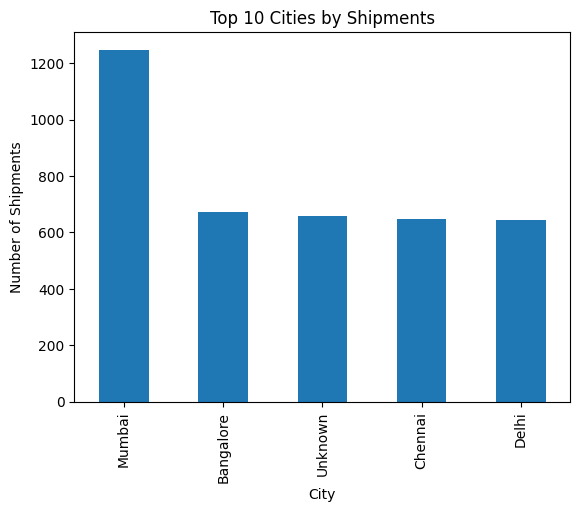

In [ ]:
top_cities = df["City"].value_counts().head(10)

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Shipments")
plt.xlabel("City")
plt.ylabel("Number of Shipments")

plt.show()

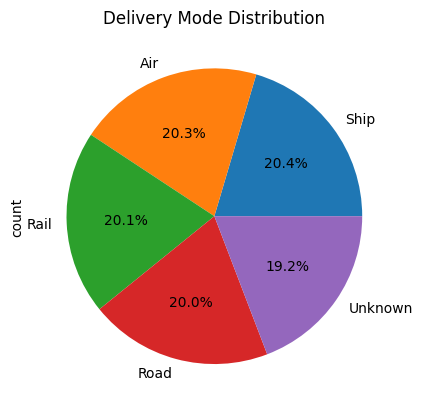

In [ ]:
df["Delivery_Mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Delivery Mode Distribution")

plt.show()

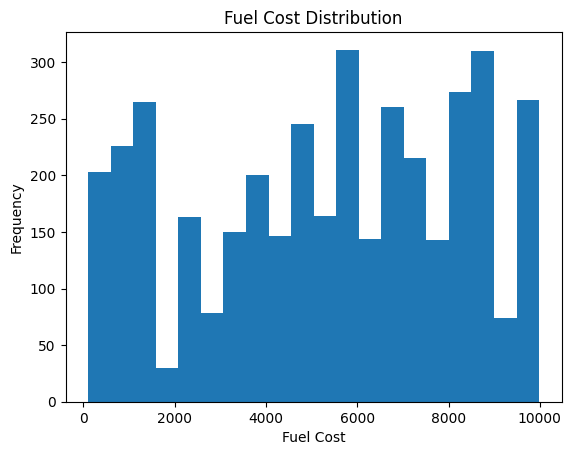

In [ ]:
df["Fuel_Cost"].plot(kind="hist", bins=20)

plt.title("Fuel Cost Distribution")
plt.xlabel("Fuel Cost")
plt.ylabel("Frequency")

plt.show()

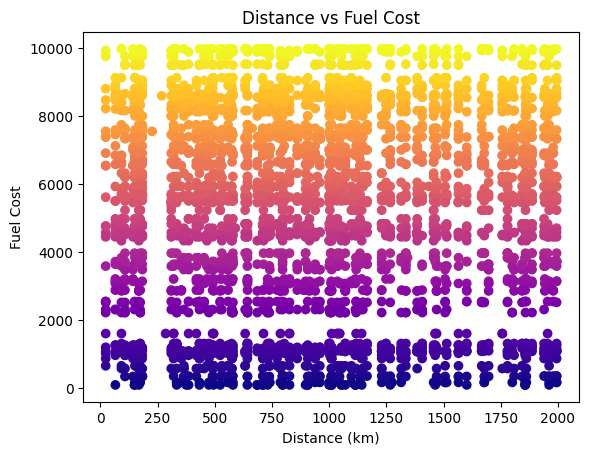

In [ ]:
plt.scatter(df["Distance_km"], df["Fuel_Cost"], c=df["Fuel_Cost"], cmap="plasma")

plt.title("Distance vs Fuel Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Fuel Cost")

plt.show()

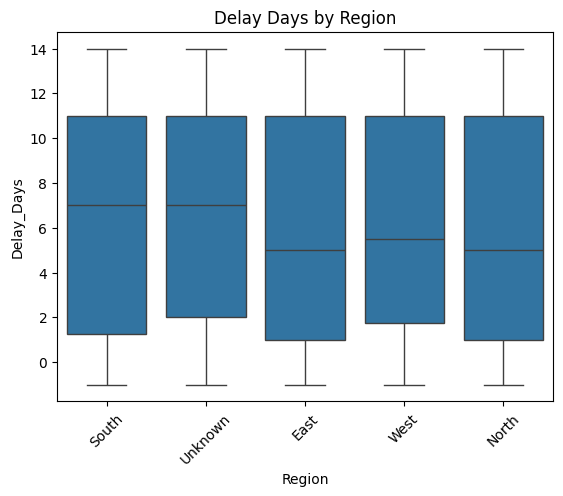

In [ ]:
sns.boxplot(x='Region', y='Delay_Days', data=df)
plt.xticks(rotation=45)
plt.title("Delay Days by Region")
plt.show()

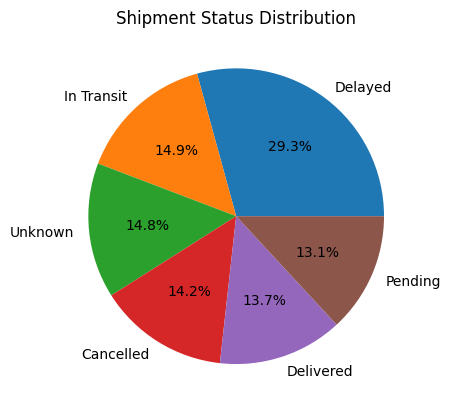

In [ ]:
df['Status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Shipment Status Distribution")
plt.ylabel("")
plt.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Top 10 Cities by Shipments",
        "Delivery Mode Distribution",
        "Fuel Cost Distribution",
        "Distance vs Fuel Cost",
        "Delay Days by Region"
    ),
    specs=[[{}, {"type":"domain"}],
           [{}, {}],
           [{"colspan":2}, None]]
)

# 1 Bar Chart
top_cities = df["City"].value_counts().head(10)

fig.add_trace(
    go.Bar(x=top_cities.index, y=top_cities.values),
    row=1, col=1
)

# 2 Pie Chart
delivery_mode = df["Delivery_Mode"].value_counts()

fig.add_trace(
    go.Pie(labels=delivery_mode.index, values=delivery_mode.values),
    row=1, col=2
)

# 3 Histogram
fig.add_trace(
    go.Histogram(x=df["Fuel_Cost"], nbinsx=20),
    row=2, col=1
)

# 4 Scatter Plot
fig.add_trace(
    go.Scatter(
        x=df["Distance_km"],
        y=df["Fuel_Cost"],
        mode='markers'
    ),
    row=2, col=2
)

# 5 Box Plot
regions = df["Region"].unique()

for region in regions:
    fig.add_trace(
        go.Box(
            y=df[df["Region"]==region]["Delay_Days"],
            name=region
        ),
        row=3, col=1
    )

fig.update_layout(
    title="Logistics Data Analysis Dashboard",
    height=900,
    showlegend=False
)

fig.show()

--------Thank You----------